# Decision Tree Example: Predicting Wide Receiver Draft Round

In this notebook, we will demonstrate the capabilities of the decision tree class in our ML package. To do so, we will take wide receiver's NFL career stats and accomplishments to predict the round of the NFL Draft they were chosen in.

This will allow us to evaluate how well teams draft wide receivers as players taken in high rounds are taken there because they are projected to have better stats and acheivements throughout their career.

In [1]:
# Import necessary libraries
import sys
import os

# Send Python to the project root so we can import our library
project_root = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/src"
sys.path.append(project_root)

# Import our ML library and other necessary libraries
import rice_ml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Import the dataset
data_path = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/data/nfl_draft_data.csv"
data = pd.read_csv(data_path)

Now that we have imported our data and package, we can prep the data for analysis.

In [3]:
# Filter the dataset to include only the relevant columns
data = data[["season", "pfr_player_name", "round", "position", "receptions",
             "rec_yards", "rec_tds", "hof", "allpro", "probowls"]]

# Only want Wide Receivers
data = data[data["position"] == "WR"]

# Only want players drafted this century
data = data[data["season"] >= 2000]
# Now we don't need the season column
data = data.drop(columns=["season"])

# Drop rows with missing values
data = data.dropna()

# View the first few rows of the dataset
print(data.head())

       pfr_player_name  round position  receptions  rec_yards  rec_tds    hof  \
6029     Peter Warrick      1       WR       275.0     2991.0     18.0  False   
6033   Plaxico Burress      1       WR       553.0     8499.0     64.0  False   
6035     Travis Taylor      1       WR       312.0     4017.0     22.0  False   
6046  Sylvester Morris      1       WR        48.0      678.0      3.0  False   
6054     R. Jay Soward      1       WR        14.0      154.0      1.0  False   

      allpro  probowls  
6029       0         0  
6033       0         0  
6035       0         0  
6046       0         0  
6054       0         0  


As stated previously, we will only analyze wide receivers in this notebook. A quick look at the data above immediately reveals some flawed draft picks. All five receivers listed were drafted in the first round, but they combined for a total of zero pro bowl and all pro appearances. Players being taken this high are expected to make a great impact, but this small group failed to live up to those expectations.

Furthermore, to better capture more recent trends, we eliminate all the players drafted before 2000. We deemed the year 2000 to be a fair balance between having a large enough sample size and capturing the recent stylistic developments in football. These developments include a much greater emphasis on the passing game, compared to older iterations of football.

By looking at pure production numbers and overall accomplishments, we effectively capture a player's entire career as very high draft picks are not only expected to be great, but be great for many years.

In [4]:
# Standardize the data using our StandardScaler class from our library
scaler = rice_ml.StandardScaler()
# Must convert hof to integer values (1 for yes, 0 for no) before scaling
data["hof"] = data["hof"].astype(int)
# Now can scale the features
scaled_data = scaler.fit_transform(data[["receptions", "rec_yards", "rec_tds", "hof", "allpro", "probowls"]].values)

# Combine scaled features with the target variable (round) into a new DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=["receptions", "rec_yards", "rec_tds", "hof", "allpro", "probowls"])
scaled_data["round"] = data["round"].values

# Bring player names back for later analysis of predictions
scaled_data["pfr_player_name"] = data["pfr_player_name"].values

# Create a 80/20 train/test split with random shuffling
scaled_data = scaled_data.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(scaled_data))
train_data = scaled_data.iloc[:train_size]
test_data = scaled_data.iloc[train_size:]

# Convert pandas DataFrames to numpy arrays for training and testing
X_train = train_data[["receptions", "rec_yards", "rec_tds", "hof", "allpro", "probowls"]].values
y_train = train_data["round"].values
X_test = test_data[["receptions", "rec_yards", "rec_tds", "hof", "allpro", "probowls"]].values
y_test = test_data["round"].values

# Train the decision tree model to predict the draft round based on the features
model = rice_ml.DecisionTree(max_depth=3)
model.train(X_train, y_train)


We standardize the data before training and set the max depth of the tree to be 3, stictly preventing overfitting

Now that we have a trained model, we can generate predictions and evaluate the model's performance.

In [5]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Evaluate the model's performance using accuracy and mean absolute error from our library
accuracy = rice_ml.accuracy_score(y_test, predictions)
mae = rice_ml.mean_absolute_error(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Accuracy: 0.2484
Mean Absolute Error: 1.7386


Our model was able to predict 24% of the wide receiver's draft round correctly. This is a decent rate considering we built this model from just three simple statistical measures of wide receiver production. A mean absolute error of about 1.7, tells us that our predictions are off by an average of 1.7 rounds, soldifying the lack of strength in our model. Because the draft is just 7 rounds, an average error of about 2 rounds is a big knock on our model.

However, the model's limitations reveal the reality of the NFL Draft: it's very difficult to project a player's talent and career from their college performance. Because of this difficulty, our model is unlikely to be very accurate. We expected better results than this because of our trust in NFL decision makers, but ultimately player evaluation is very difficult.

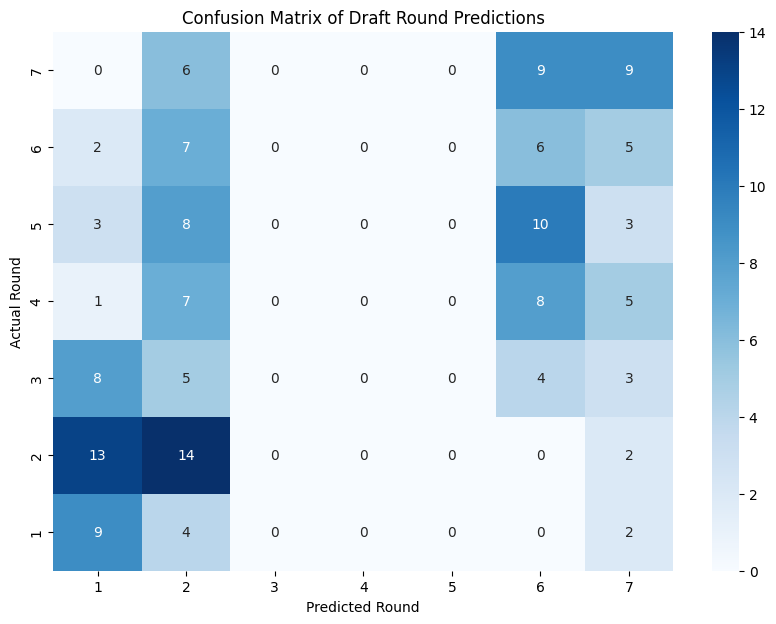

In [6]:
# Create a confusion matrix to visualize the performance of the model

# Import necessary libraries for confusion matrix and visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix using sklearn's function
cm = confusion_matrix(y_test, predictions)

# Define the actual round numbers you want on the axes
draft_rounds = [1, 2, 3, 4, 5, 6, 7]

# Create plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=draft_rounds, 
            yticklabels=draft_rounds)
plt.xlabel("Predicted Round")
plt.ylabel("Actual Round")
plt.title("Confusion Matrix of Draft Round Predictions")
plt.gca().invert_yaxis()
plt.show()

The confusion matrix confirms our model's lack of predictive power as the values do not hug the diagnol (bottom left to top right) of the matrix. This diagnol is where predicted equals actual, so we would expect an effective model to have most of the values on or around this line for a classifcation. 

More signficantly, our model doesn't predict players to be in rounds 3-5. This is a major flaw in the model as it limits our accuracy heavily. Ignoring this limitation, our model does a good job separating good and bad players, but the unpredictability of the draft and the players that are taken really hinders our models effectiveness. 

Despite the lack of strength, the model is relatively effective at predicting players who get drafted in one of the top two rounds. These players get a headstart on their NFL careers because when you are drafted higher you are trusted more quickly. These players are also supposedly more talented and skilled than players drafted after them. Together this seems to be why player career's are more stable and predictable at the top. Once you get to lower rounds, variability increases in terms of players' career lengths and performances, explaining why our model gets weaker in the later rounds of the draft.

In [7]:
# Create table of players who the model's predictions were the worst
worst_predictions = test_data.copy()
worst_predictions["predicted_round"] = predictions
worst_predictions["error"] = abs(worst_predictions["round"] - worst_predictions["predicted_round"])
worst_predictions = worst_predictions.sort_values(by="error", ascending=False)
print(worst_predictions[["pfr_player_name", "round", "predicted_round", "error"]].head(5))

    pfr_player_name  round  predicted_round  error
709    A.J. Jenkins      1                7      6
642   R. Jay Soward      1                7      6
699    Ronald Curry      7                2      5
646      Trey Quinn      7                2      5
763     Devin Smith      2                7      5


This group of players are five of the players where the model was terribly wrong. Ronald Curry and Trey Quinn, according to the model, overperformed their draft position by turning themselves from a seventh round draft pick to what the model deemed to be a second round quality career. Curry had a solid career totaling over 2000 yards over around 7 seasons, much more valuable than a typical 7th round pick.

Conversely, AJ Jenkins and R Jay Soward were rated as seventh round quality by the model, but were drafted in the first round. Jenkins was a complete bust pick and the model correctly identified him as a poor first round pick. He totaled just over 200 yards in his short 3 year career. The model also correctly identified Soward as an even bigger bust than Jenkins. His career just lasted one year with him totaling just over 100 yards. However, while he wasn't particularly prductive in this short time, he derailed his own career by violating the substance abuse policy more than three times, leading to his indefinite suspension. These examples reveal some strength in our model.

Ultimately, our model failed to truly distinguish the round players are drafted in based on their career, revealing the flaws in the current processes of player evaluations.